In [1]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e9/sample_submission.csv
/kaggle/input/playground-series-s5e9/train.csv
/kaggle/input/playground-series-s5e9/test.csv


# Predicting the Beats-per-Minute of Songs

- The goal of this competition is to predict a song's beats-per-minute.
- Submissions are evaluated using the Root Mean Squared Error between the predicted and the observed target.

## Environment Setup & Configuration

### Imports

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import warnings
import os
import gc
from typing import Dict, List, Tuple, Optional, Union
from dataclasses import dataclass
from pathlib import Path

# Scientific computing
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Sklearn - Preprocessing and Metrics
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    KFold,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    MinMaxScaler,
    PowerTransformer,
    QuantileTransformer,
    PolynomialFeatures
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# Sklearn - Models
# from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    # ExtraTreesRegressor,
    # GradientBoostingRegressor,
    # HistGradientBoostingRegressor,
    # VotingRegressor,
    # StackingRegressor,
    # BaggingRegressor,
    # AdaBoostRegressor
)
# from sklearn.svm import SVR
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.neural_network import MLPRegressor

# Advanced models
# import xgboost as xgb
# import lightgbm as lgb
# import catboost as cb

# Hyperparameter optimization
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

c:\Users\Florent\Documents\data_science\kaggle-predicting-bpm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Config

In [2]:
@dataclass
class Config:
    """Configuration parameters for the entire pipeline."""

    def __init__(self):
        # Auto-detect environment and set paths
        self._detect_environment()

        # Data split
        self.test_size: float = 0.2
        self.n_folds: int = 5

        # Model parameters
        self.random_state: int = 42
        self.n_jobs: int = -1

        # Optimization
        self.optuna_trials: int = 100
        self.early_stopping_rounds: int = 50

        # Feature engineering
        self.create_polynomial: bool = True
        self.polynomial_degree: int = 2

        # Outlier detection
        self.outlier_threshold: float = 1.5

        # Ensemble
        self.use_stacking: bool = True
        self.use_blending: bool = True

    def _detect_environment(self):
        """Auto-detect environment and set appropriate paths"""
        if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or os.path.exists('/kaggle/input'):
            # Kaggle environment
            self.env = 'kaggle'
            self.data_path = '/kaggle/input/playground-series-s5e9/'
            self.output_path = '/kaggle/working/'
        else:
            # Local environment
            self.env = 'local'
            base_path = Path.cwd()
            if base_path.name == 'notebooks':
                base_path = base_path.parent
            self.data_path = str(base_path / 'data' / 'kaggle' / 'input')
            self.output_path = str(base_path / 'data' / 'kaggle' / 'working')

        print(f"Environment: {self.env}")
        print(f"Data path: {self.data_path}")
        print(f"Output path: {self.output_path}")

In [3]:
config = Config()

Environment: local
Data path: c:\Users\Florent\Documents\data_science\kaggle-predicting-bpm\data\kaggle\input
Output path: c:\Users\Florent\Documents\data_science\kaggle-predicting-bpm\data\kaggle\working


## Data Loading

In [4]:
class DataLoader:
    """Handles data loading and initial validation."""
    
    def __init__(self, config: Config):
        self.config = config
        self.train = None
        self.test = None
        self.sample_submission = None
        
    def load_data(self) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """Load all datasets and perform initial validation."""
        
        print("Loading datasets...")
        self.train = pd.read_csv(os.path.join(self.config.data_path, "train.csv"))
        self.test = pd.read_csv(os.path.join(self.config.data_path, "test.csv"))
        self.sample_submission = pd.read_csv(
            os.path.join(self.config.data_path, "sample_submission.csv")
        )
        
        # Memory usage
        train_memory = self.train.memory_usage(deep=True).sum() / (1024**2)
        test_memory = self.test.memory_usage(deep=True).sum() / (1024**2)
        
        print(f"✓ Train dataset loaded: {self.train.shape} - Memory: {train_memory:.2f} MB")
        print(f"✓ Test dataset loaded: {self.test.shape} - Memory: {test_memory:.2f} MB")
        print(f"✓ Sample submission loaded: {self.sample_submission.shape}")
        
        # Validate data integrity
        self._validate_data()
        
        return self.train, self.test, self.sample_submission
    
    def _validate_data(self):
        """Validate data integrity and consistency."""
        
        print("\nValidating data integrity...")
        
        # Check for ID columns
        if 'id' in self.train.columns:
            assert self.train['id'].nunique() == len(self.train), "Duplicate IDs in train"
            print("✓ Train IDs are unique")
            
        if 'id' in self.test.columns:
            assert self.test['id'].nunique() == len(self.test), "Duplicate IDs in test"
            print("✓ Test IDs are unique")
        
        # Check target variable
        assert 'BeatsPerMinute' in self.train.columns, "Target variable missing"
        print(f"✓ Target variable present: BeatsPerMinute")
        
        # Check feature consistency
        train_features = set(self.train.columns) - {'BeatsPerMinute', 'id'}
        test_features = set(self.test.columns) - {'id'}
        
        assert train_features == test_features, "Feature mismatch between train and test"
        print(f"✓ Feature consistency validated: {len(train_features)} features")


In [5]:
data_loader = DataLoader(config)
train, test, sample_submission = data_loader.load_data()

Loading datasets...
✓ Train dataset loaded: (524164, 11) - Memory: 43.99 MB
✓ Test dataset loaded: (174722, 10) - Memory: 13.33 MB
✓ Sample submission loaded: (174722, 2)

Validating data integrity...
✓ Train IDs are unique
✓ Test IDs are unique
✓ Target variable present: BeatsPerMinute
✓ Feature consistency validated: 9 features


## EDA

In [6]:
class EDAAnalyzer:
    """Comprehensive Exploratory Data Analysis."""
    
    def __init__(self, train: pd.DataFrame, test: pd.DataFrame):
        self.train = train
        self.test = test
        self.target = 'BeatsPerMinute'
        self.numerical_features = None
        self.categorical_features = None
        
    def perform_complete_eda(self):
        """Execute complete EDA pipeline."""
        
        print("="*80)
        print("EXPLORATORY DATA ANALYSIS")
        print("="*80)
        
        self._basic_info()
        self._identify_feature_types()
        self._missing_values_analysis()
        self._duplicate_analysis()
        self._statistical_summary()
        self._target_analysis()
        self._outlier_detection()
        self._correlation_analysis()
        self._distribution_analysis()
        self._feature_relationships()
        
    def _basic_info(self):
        """Display basic dataset information."""
        
        print("\nBASIC INFORMATION")
        print("-"*40)
        print(f"Train shape: {self.train.shape}")
        print(f"Test shape: {self.test.shape}")
        print(f"\nFeatures: {list(self.train.columns)}")
        print(f"\nData types:")
        print(self.train.dtypes.value_counts())
        
    def _identify_feature_types(self):
        """Identify numerical and categorical features."""
        
        self.numerical_features = self.train.select_dtypes(
            include=[np.number]
        ).columns.tolist()
        
        self.categorical_features = self.train.select_dtypes(
            include=['object', 'category']
        ).columns.tolist()
        
        # Remove target and id from features
        if self.target in self.numerical_features:
            self.numerical_features.remove(self.target)
        if 'id' in self.numerical_features:
            self.numerical_features.remove('id')
            
        print(f"\nNumerical features ({len(self.numerical_features)}): {self.numerical_features}")
        print(f"Categorical features ({len(self.categorical_features)}): {self.categorical_features}")
        
    def _missing_values_analysis(self):
        """Analyze missing values in datasets."""
        
        print("\nMISSING VALUES ANALYSIS")
        print("-"*40)
        
        for name, df in [("Train", self.train), ("Test", self.test)]:
            missing = df.isnull().sum()
            missing_pct = (missing / len(df)) * 100
            
            if missing.sum() > 0:
                missing_df = pd.DataFrame({
                    'Missing_Count': missing[missing > 0],
                    'Percentage': missing_pct[missing > 0]
                }).sort_values('Percentage', ascending=False)
                
                print(f"\n{name} dataset missing values:")
                print(missing_df)
                
                # Visualize missing patterns
                plt.figure(figsize=(12, 6))
                msno.matrix(df)
                plt.title(f'Missing Values Pattern - {name} Dataset')
                plt.show()
            else:
                print(f"{name} dataset: No missing values found")
                
    def _duplicate_analysis(self):
        """Detect and analyze duplicate rows."""
        
        print("\nDUPLICATE ANALYSIS")
        print("-"*40)
        
        # Check for complete duplicates
        train_duplicates = self.train.duplicated().sum()
        test_duplicates = self.test.duplicated().sum()
        
        print(f"Train duplicates: {train_duplicates}")
        print(f"Test duplicates: {test_duplicates}")
        
        # Check for duplicate features (excluding target)
        train_features = self.train.drop(columns=[self.target, 'id'], errors='ignore')
        duplicate_features = train_features.duplicated().sum()
        
        if duplicate_features > 0:
            print(f"Found {duplicate_features} duplicate feature combinations")
            
    def _statistical_summary(self):
        """Generate comprehensive statistical summary."""
        
        print("\nSTATISTICAL SUMMARY")
        print("-"*40)
        
        # Custom percentiles
        percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
        
        print("\nTrain dataset statistics:")
        display(self.train.describe(percentiles=percentiles))
        
        # Skewness and Kurtosis
        print("\nDistribution Shape Analysis:")
        skew_kurt_df = pd.DataFrame({
            'Skewness': self.train[self.numerical_features + [self.target]].skew(),
            'Kurtosis': self.train[self.numerical_features + [self.target]].kurtosis()
        }).sort_values('Skewness', ascending=False)
        
        display(skew_kurt_df)
        
    def _target_analysis(self):
        """Analyze target variable distribution."""
        
        print("\nTARGET VARIABLE ANALYSIS")
        print("-"*40)
        
        target_stats = {
            'Mean': self.train[self.target].mean(),
            'Median': self.train[self.target].median(),
            'Std': self.train[self.target].std(),
            'Min': self.train[self.target].min(),
            'Max': self.train[self.target].max(),
            'Skewness': self.train[self.target].skew(),
            'Kurtosis': self.train[self.target].kurtosis()
        }
        
        print("Target Statistics:")
        for key, value in target_stats.items():
            print(f"  {key}: {value:.4f}")
            
        # Visualization
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Distribution
        axes[0].hist(self.train[self.target], bins=50, edgecolor='black', alpha=0.7)
        axes[0].axvline(target_stats['Mean'], color='red', linestyle='--', label='Mean')
        axes[0].axvline(target_stats['Median'], color='green', linestyle='--', label='Median')
        axes[0].set_title('Target Distribution')
        axes[0].set_xlabel(self.target)
        axes[0].legend()
        
        # Q-Q plot
        from scipy import stats
        stats.probplot(self.train[self.target], dist="norm", plot=axes[1])
        axes[1].set_title('Q-Q Plot')
        
        # Box plot
        axes[2].boxplot(self.train[self.target])
        axes[2].set_title('Target Boxplot')
        axes[2].set_ylabel(self.target)
        
        plt.tight_layout()
        plt.show()
        
    def _outlier_detection(self):
        """Detect outliers using multiple methods."""
        
        print("\nOUTLIER DETECTION")
        print("-"*40)
        
        outlier_summary = {}
        
        for col in self.numerical_features + [self.target]:
            # IQR method
            Q1 = self.train[col].quantile(0.25)
            Q3 = self.train[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers_iqr = ((self.train[col] < lower_bound) | 
                            (self.train[col] > upper_bound)).sum()
            
            # Z-score method
            z_scores = np.abs(stats.zscore(self.train[col].dropna()))
            outliers_zscore = (z_scores > 3).sum()
            
            outlier_summary[col] = {
                'IQR_outliers': outliers_iqr,
                'IQR_pct': (outliers_iqr / len(self.train)) * 100,
                'Zscore_outliers': outliers_zscore,
                'Lower_bound': lower_bound,
                'Upper_bound': upper_bound
            }
        
        outlier_df = pd.DataFrame(outlier_summary).T
        outlier_df = outlier_df.sort_values('IQR_pct', ascending=False)
        
        print("\nOutlier Summary (sorted by percentage):")
        display(outlier_df)
        
        # Visualize outliers
        fig, ax = plt.subplots(figsize=(14, 6))
        self.train[self.numerical_features + [self.target]].boxplot(ax=ax)
        plt.xticks(rotation=45)
        plt.title('Outlier Detection - Boxplots')
        plt.tight_layout()
        plt.show()
        
    def _correlation_analysis(self):
        """Analyze feature correlations."""
        
        print("\nCORRELATION ANALYSIS")
        print("-"*40)
        
        # Calculate correlations
        corr_matrix = self.train[self.numerical_features + [self.target]].corr()
        
        # Target correlations
        target_corr = corr_matrix[self.target].sort_values(ascending=False)
        
        print(f"\nTop Features Correlated with {self.target}:")
        display(target_corr[1:11])  # Top 10 excluding target itself
        
        # Heatmap
        plt.figure(figsize=(12, 10))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(
            corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            linewidths=0.5
        )
        plt.title('Feature Correlation Matrix')
        plt.tight_layout()
        plt.show()
        
        # High correlation pairs
        print("\nHighly Correlated Feature Pairs (|r| > 0.8):")
        high_corr_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i, j]) > 0.8:
                    high_corr_pairs.append({
                        'Feature_1': corr_matrix.columns[i],
                        'Feature_2': corr_matrix.columns[j],
                        'Correlation': corr_matrix.iloc[i, j]
                    })
        
        if high_corr_pairs:
            display(pd.DataFrame(high_corr_pairs))
        else:
            print("No highly correlated pairs found")
            
    def _distribution_analysis(self):
        """Analyze feature distributions."""
        
        print("\nDISTRIBUTION ANALYSIS")
        print("-"*40)
        
        # Plot distributions
        n_features = len(self.numerical_features)
        n_cols = 4
        n_rows = (n_features + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
        axes = axes.flatten() if n_features > 1 else [axes]
        
        for idx, col in enumerate(self.numerical_features):
            axes[idx].hist(self.train[col], bins=30, edgecolor='black', alpha=0.7)
            axes[idx].set_title(f'{col} Distribution')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Frequency')
            
            # Add skewness text
            skew = self.train[col].skew()
            axes[idx].text(
                0.7, 0.95,
                f'Skew: {skew:.2f}',
                transform=axes[idx].transAxes,
                fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            )
        
        # Hide unused subplots
        for idx in range(len(self.numerical_features), len(axes)):
            axes[idx].set_visible(False)
            
        plt.tight_layout()
        plt.show()
        
    def _feature_relationships(self):
        """Analyze relationships between features and target."""
        
        print("\nFEATURE-TARGET RELATIONSHIPS")
        print("-"*40)
        
        # Select top correlated features
        corr_with_target = self.train[self.numerical_features].corrwith(
            self.train[self.target]
        ).abs().sort_values(ascending=False)
        
        top_features = corr_with_target.head(6).index.tolist()
        
        # Create scatter plots
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        for idx, feature in enumerate(top_features):
            axes[idx].scatter(
                self.train[feature],
                self.train[self.target],
                alpha=0.5,
                s=10
            )
            
            # Add regression line
            z = np.polyfit(self.train[feature], self.train[self.target], 1)
            p = np.poly1d(z)
            axes[idx].plot(
                self.train[feature].sort_values(),
                p(self.train[feature].sort_values()),
                "r--",
                alpha=0.8,
                linewidth=2
            )
            
            axes[idx].set_xlabel(feature)
            axes[idx].set_ylabel(self.target)
            axes[idx].set_title(f'{feature} vs {self.target}\n(r={corr_with_target[feature]:.3f})')
            
        plt.tight_layout()
        plt.show()

EXPLORATORY DATA ANALYSIS

BASIC INFORMATION
----------------------------------------
Train shape: (524164, 11)
Test shape: (174722, 10)

Features: ['id', 'RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality', 'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore', 'TrackDurationMs', 'Energy', 'BeatsPerMinute']

Data types:
float64    10
int64       1
Name: count, dtype: int64

Numerical features (9): ['RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality', 'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore', 'TrackDurationMs', 'Energy']
Categorical features (0): []

MISSING VALUES ANALYSIS
----------------------------------------
Train dataset: No missing values found
Test dataset: No missing values found

DUPLICATE ANALYSIS
----------------------------------------
Train duplicates: 0
Test duplicates: 0

STATISTICAL SUMMARY
----------------------------------------

Train dataset statistics:


,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,262081.500000,0.632843,-8.379014,0.074443,0.262913,0.117690,0.178398,0.555843,241903.692949,0.500923,119.034899
std,151313.257587,0.156899,4.616221,0.049939,0.223120,0.131845,0.118186,0.225480,59326.601501,0.289952,26.468077
min,0.000000,0.076900,-27.509725,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067,46.718000
1%,5241.630000,0.329928,-19.751184,0.023500,0.000005,0.000001,0.024300,0.025600,104930.124100,0.011200,58.521310
5%,26208.150000,0.381798,-16.144061,0.023500,0.000005,0.000001,0.024300,0.079889,141854.686970,0.050133,75.651300
25%,131040.750000,0.515850,-11.551933,0.023500,0.069413,0.000001,0.077637,0.403921,207099.876625,0.254933,101.070410
50%,262081.500000,0.634686,-8.252499,0.066425,0.242502,0.074247,0.166327,0.564817,243684.058150,0.511800,118.747660
75%,393122.250000,0.739179,-4.912298,0.107343,0.396957,0.204065,0.268946,0.716633,281851.658500,0.746000,136.686590
95%,497954.850000,0.915898,-1.357000,0.170769,0.652046,0.384216,0.387061,0.945899,337567.499745,0.946133,163.532050



Distribution Shape Analysis:


,Skewness,Kurtosis
InstrumentalScore,1.036285,0.156410
VocalContent,0.789112,-0.147707
AcousticQuality,0.785966,0.267141
LivePerformanceLikelihood,0.393322,-0.754137
RhythmScore,0.168155,-0.526732
BeatsPerMinute,0.071550,-0.154465
Energy,-0.030344,-1.209077
TrackDurationMs,-0.190483,-0.129154
MoodScore,-0.268820,-0.142274
AudioLoudness,-0.308514,-0.388404



TARGET VARIABLE ANALYSIS
----------------------------------------
Target Statistics:
  Mean: 119.0349
  Median: 118.7477
  Std: 26.4681
  Min: 46.7180
  Max: 206.0370
  Skewness: 0.0715
  Kurtosis: -0.1545


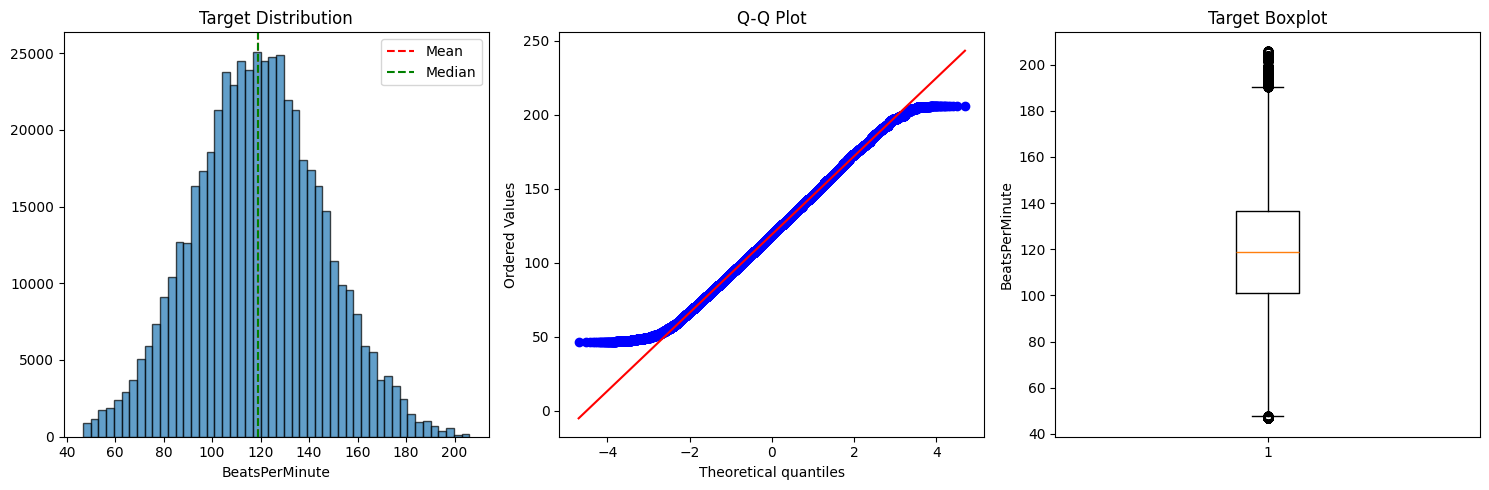


OUTLIER DETECTION
----------------------------------------

Outlier Summary (sorted by percentage):


,IQR_outliers,IQR_pct,Zscore_outliers,Lower_bound,Upper_bound
AcousticQuality,6746.0,1.287002,6007.0,-0.421902,0.888272
TrackDurationMs,4267.0,0.814058,23.0,94972.203812,393979.331313
InstrumentalScore,2845.0,0.542769,2668.0,-0.306096,0.510162
BeatsPerMinute,2141.0,0.408460,505.0,47.646140,190.110860
AudioLoudness,1770.0,0.337681,1213.0,-21.511386,5.047154
VocalContent,1245.0,0.237521,3146.0,-0.102264,0.233107
LivePerformanceLikelihood,129.0,0.024611,232.0,-0.209327,0.555910
RhythmScore,8.0,0.001526,7.0,0.180855,1.074174
MoodScore,0.0,0.000000,0.0,-0.065147,1.185700
Energy,0.0,0.000000,0.0,-0.481667,1.482600


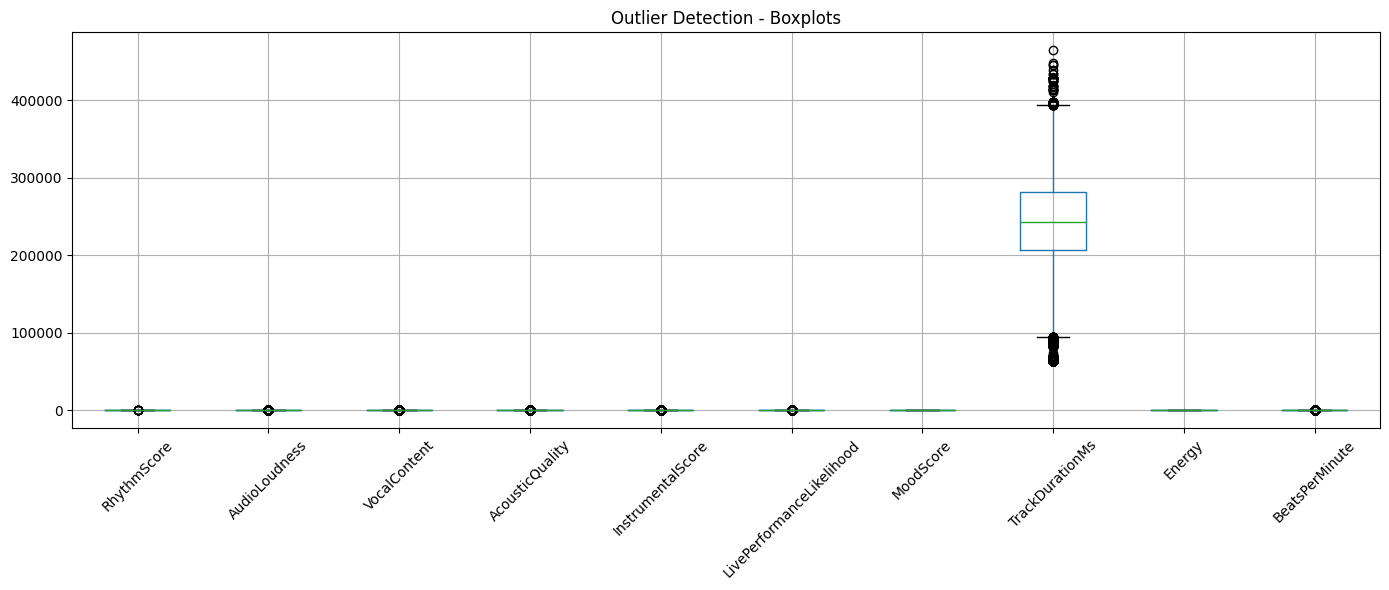


CORRELATION ANALYSIS
----------------------------------------

Top Features Correlated with BeatsPerMinute:


MoodScore                    0.007059
TrackDurationMs              0.006637
RhythmScore                  0.005440
VocalContent                 0.004876
LivePerformanceLikelihood    0.003471
InstrumentalScore            0.001900
AcousticQuality             -0.000820
AudioLoudness               -0.003327
Energy                      -0.004375
Name: BeatsPerMinute, dtype: float64

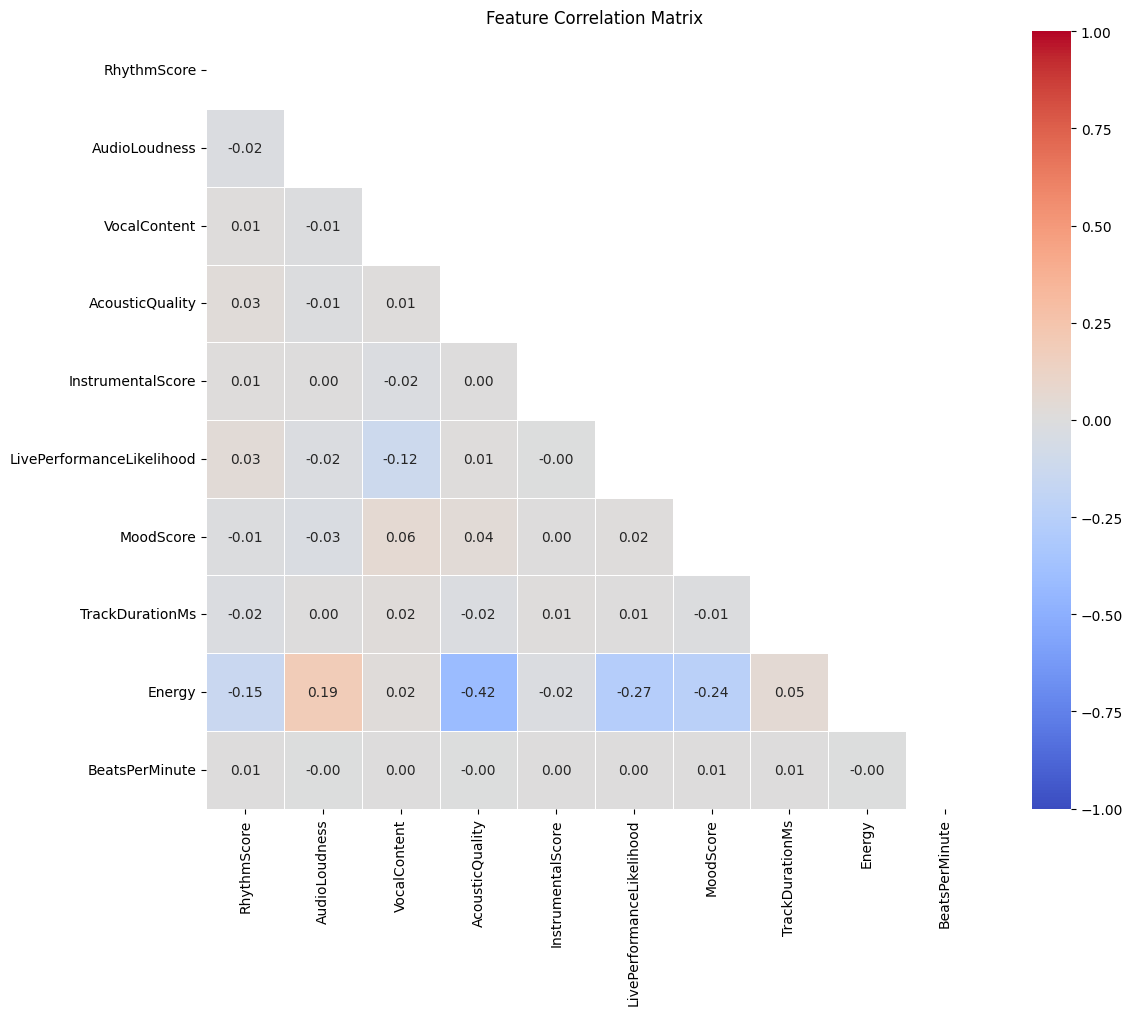


Highly Correlated Feature Pairs (|r| > 0.8):
No highly correlated pairs found

DISTRIBUTION ANALYSIS
----------------------------------------


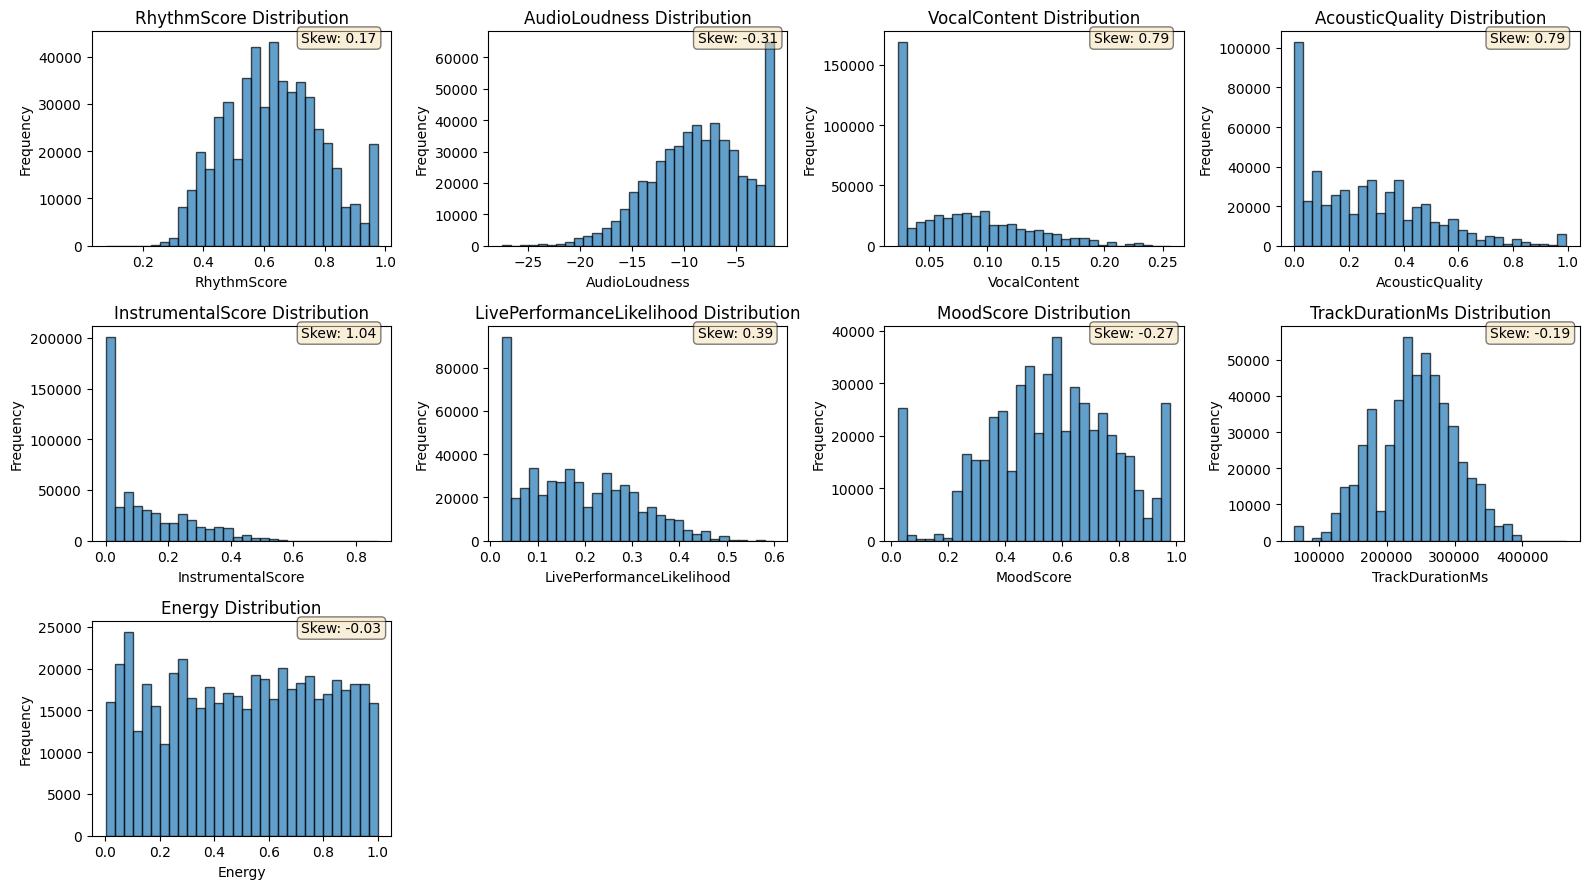


FEATURE-TARGET RELATIONSHIPS
----------------------------------------


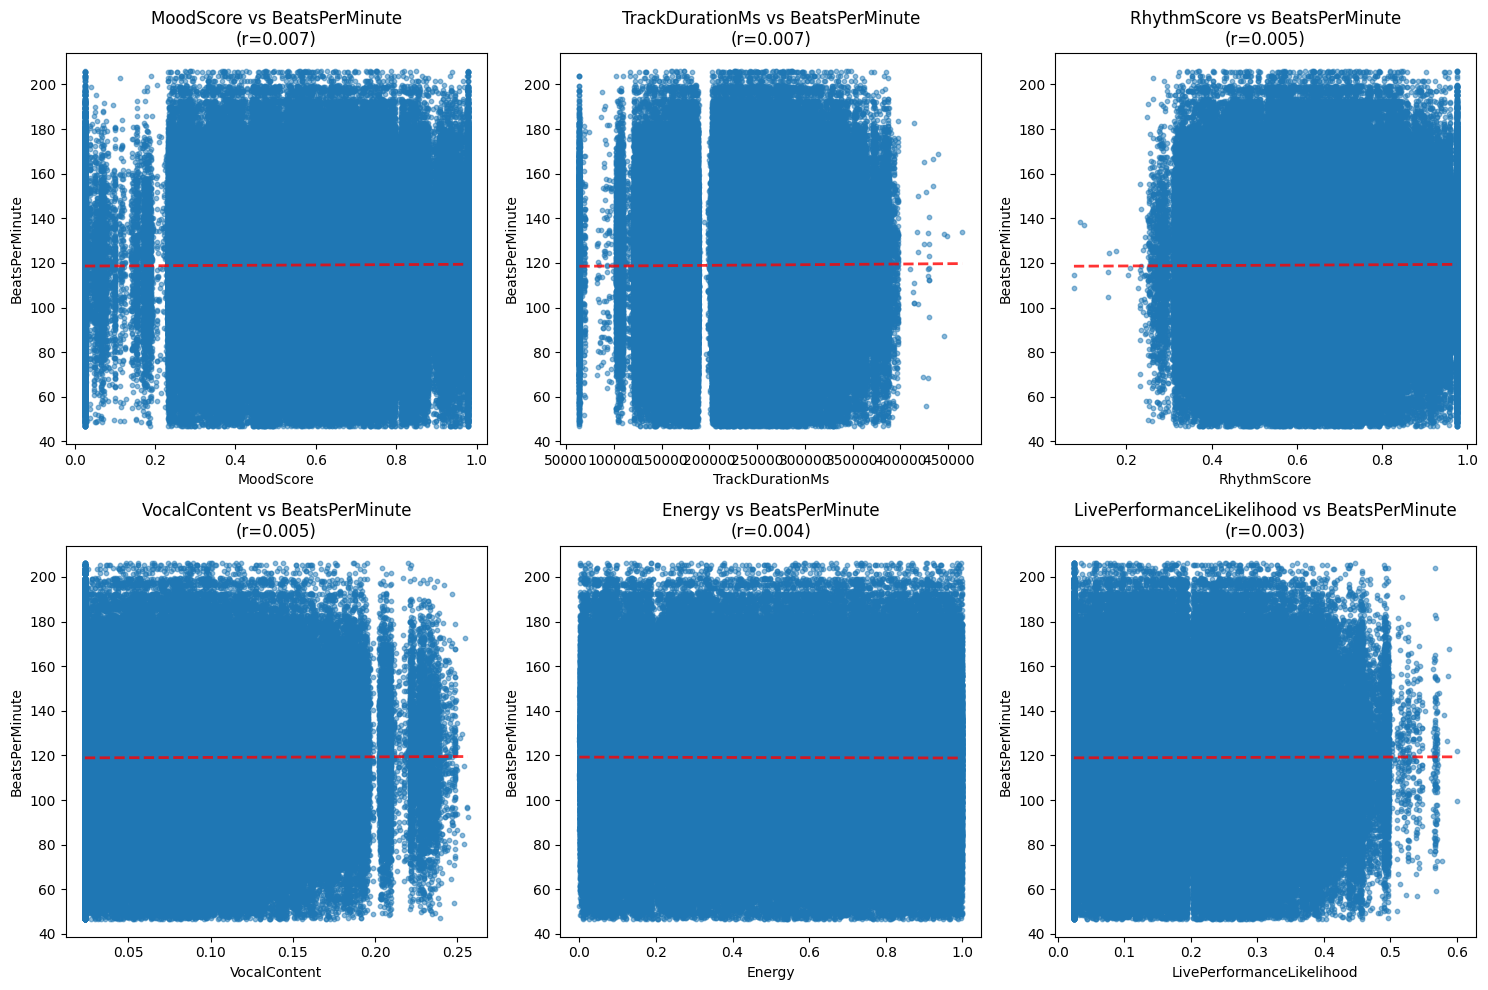

In [7]:
eda = EDAAnalyzer(train, test)
eda.perform_complete_eda()

## Data preprocessing and cleaning

## Feature Engineering

In [ ]:
def feature_engineering_decision_tree(df, target_col):
    """
    Guide de décision pour le feature engineering
    """
    
    print("🔍 ANALYSE POUR FEATURE ENGINEERING")
    print("="*50)
    
    # 1. ANALYSER LA DISTRIBUTION DES FEATURES
    print("\n1️⃣ ANALYSE DES DISTRIBUTIONS")
    for col in df.columns:
        skewness = df[col].skew()
        
        if abs(skewness) > 1:
            print(f"❗ {col}: Fortement asymétrique (skew={skewness:.2f})")
            print(f"   → Appliquer: Log transformation ou Box-Cox")
        elif abs(skewness) > 0.5:
            print(f"⚠️  {col}: Légèrement asymétrique (skew={skewness:.2f})")
            print(f"   → Appliquer: Square root transformation")
        else:
            print(f"✅ {col}: Distribution normale (skew={skewness:.2f})")
            print(f"   → Pas de transformation nécessaire")
    
    # 2. ANALYSER LES CORRÉLATIONS
    print("\n2️⃣ ANALYSE DES CORRÉLATIONS")
    corr_matrix = df.corr()
    high_corr_pairs = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_value = abs(corr_matrix.iloc[i, j])
            
            if corr_value > 0.9:
                print(f"❗ {corr_matrix.columns[i]} - {corr_matrix.columns[j]}: r={corr_value:.2f}")
                print(f"   → Supprimer une des deux OU créer un ratio")
            elif corr_value > 0.7:
                print(f"⚠️  {corr_matrix.columns[i]} - {corr_matrix.columns[j]}: r={corr_value:.2f}")
                print(f"   → Créer des interactions (multiplication, division)")
    
    # 3. ANALYSER LA RELATION AVEC LA TARGET
    print("\n3️⃣ ANALYSE FEATURE-TARGET")
    for col in df.columns:
        if col != target_col:
            # Corrélation linéaire
            linear_corr = df[col].corr(df[target_col])
            
            # Test de non-linéarité (simple)
            df_sorted = df.sort_values(col)
            lower_third = df_sorted.head(len(df)//3)[target_col].mean()
            middle_third = df_sorted.iloc[len(df)//3:2*len(df)//3][target_col].mean()
            upper_third = df_sorted.tail(len(df)//3)[target_col].mean()
            
            if abs(linear_corr) < 0.1:
                print(f"❌ {col}: Pas de corrélation linéaire (r={linear_corr:.2f})")
                print(f"   → Essayer: Polynômes, binning, ou interactions")
            elif lower_third < middle_third < upper_third or lower_third > middle_third > upper_third:
                print(f"📈 {col}: Relation monotone (r={linear_corr:.2f})")
                print(f"   → Garder tel quel ou transformation simple")
            else:
                print(f"〰️ {col}: Relation non-linéaire détectée")
                print(f"   → Appliquer: Polynômes degré 2-3, splines, ou binning")

In [9]:
feature_engineering_decision_tree(train, 'BeatsPerMinute')

🔍 ANALYSE POUR FEATURE ENGINEERING

1️⃣ ANALYSE DES DISTRIBUTIONS
✅ id: Distribution normale (skew=0.00)
   → Pas de transformation nécessaire
✅ RhythmScore: Distribution normale (skew=0.17)
   → Pas de transformation nécessaire
✅ AudioLoudness: Distribution normale (skew=-0.31)
   → Pas de transformation nécessaire
⚠️  VocalContent: Légèrement asymétrique (skew=0.79)
   → Appliquer: Square root transformation
⚠️  AcousticQuality: Légèrement asymétrique (skew=0.79)
   → Appliquer: Square root transformation
❗ InstrumentalScore: Fortement asymétrique (skew=1.04)
   → Appliquer: Log transformation ou Box-Cox
✅ LivePerformanceLikelihood: Distribution normale (skew=0.39)
   → Pas de transformation nécessaire
✅ MoodScore: Distribution normale (skew=-0.27)
   → Pas de transformation nécessaire
✅ TrackDurationMs: Distribution normale (skew=-0.19)
   → Pas de transformation nécessaire
✅ Energy: Distribution normale (skew=-0.03)
   → Pas de transformation nécessaire
✅ BeatsPerMinute: Distributi

No linear relationship between the features and the targert, no pattern...

TABLEAU DE DÉCISION POUR CHAQUE TECHNIQUE  

| Situation observée | Technique à appliquer | Pourquoi | Code exemple |
| Skewness > 1 | Log transformation | Normalise la distribution | df['feat_log'] = np.log1p(df['feat']) |
| Valeurs négatives + skewedBox-Cox avec shift | Gère les négatifs | PowerTransformer(method='yeo-johnson') |
| Outliers > 10% | Binning/Quantiles | Réduit l'impact des outliers | pd.qcut(df['feat'], q=5) | 
| Relation non-linéaire avec target | Polynômes | Capture les courbes | df['feat²'] = df['feat']**2 | 
| 2 features très corrélées (r>0.9) | Ratio ou PCA | Évite la multicolinéarité | df['ratio'] = df['f1']/df['f2'] | 
| Pattern cyclique | Sin/Cos transformation | Capture la périodicité | np.sin(2*np.pi*df['feat']) | 
| Beaucoup de zéros | Indicateur binaire | Flag présence/absence | df['has_value'] = (df['feat'] > 0).astype(int) | 
| Échelles très différentes | Normalization | Équilibre les features | StandardScaler() ou RobustScaler() |

In [12]:
def analyze_bpm_challenge(df):
    """
    Analyse approfondie pour comprendre pourquoi pas de corrélations
    """
    print("🔬 DIAGNOSTIC APPROFONDI")
    print("="*50)
    
    # 1. Vérifier si c'est un problème de relations non-linéaires
    print("\n1️⃣ TEST DE NON-LINÉARITÉ")
    
    for col in ['RhythmScore', 'Energy', 'MoodScore', 'TrackDurationMs']:
        # Diviser en quantiles et voir si la moyenne du BPM varie
        quartiles = pd.qcut(df[col], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
        bpm_by_quartile = df.groupby(quartiles)['BeatsPerMinute'].agg(['mean', 'std'])
        
        print(f"\n{col}:")
        print(bpm_by_quartile)
        
        # Si la variance entre quartiles est grande = relation non-linéaire
        if bpm_by_quartile['mean'].std() > 5:
            print(f"  → ✅ Relation non-linéaire détectée!")
        else:
            print(f"  → ❌ Pas de pattern clair")
    
    # 2. Rechercher des interactions cachées
    print("\n2️⃣ RECHERCHE D'INTERACTIONS")
    
    # Créer des ratios musicalement sensés
    df['energy_rhythm_ratio'] = df['Energy'] / (df['RhythmScore'] + 1e-8)
    df['mood_energy_product'] = df['MoodScore'] * df['Energy']
    df['acoustic_instrumental_ratio'] = df['AcousticQuality'] / (df['InstrumentalScore'] + 1e-8)
    
    # Tester ces nouvelles features
    new_features = ['energy_rhythm_ratio', 'mood_energy_product', 'acoustic_instrumental_ratio']
    for feat in new_features:
        corr = df[feat].corr(df['BeatsPerMinute'])
        print(f"{feat}: r={corr:.3f}")

In [13]:
analyze_bpm_challenge(train)

🔬 DIAGNOSTIC APPROFONDI

1️⃣ TEST DE NON-LINÉARITÉ

RhythmScore:
                   mean        std
RhythmScore                       
Q1           118.778667  26.529028
Q2           119.017561  26.388160
Q3           119.226264  26.485011
Q4           119.117081  26.468161
  → ❌ Pas de pattern clair

Energy:
              mean        std
Energy                       
Q1      119.213765  26.173500
Q2      119.016492  26.462955
Q3      119.014204  26.620755
Q4      118.895081  26.612035
  → ❌ Pas de pattern clair

MoodScore:
                 mean        std
MoodScore                       
Q1         118.931638  26.508965
Q2         118.861782  26.495427
Q3         119.086576  26.516189
Q4         119.259634  26.349909
  → ❌ Pas de pattern clair

TrackDurationMs:
                       mean        std
TrackDurationMs                       
Q1               118.754644  26.506915
Q2               118.941470  26.547509
Q3               119.308980  26.352171
Q4               119.134505  26.

C:\Users\Florent\AppData\Local\Temp\ipykernel_15776\734700701.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bpm_by_quartile = df.groupby(quartiles)['BeatsPerMinute'].agg(['mean', 'std'])
C:\Users\Florent\AppData\Local\Temp\ipykernel_15776\734700701.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bpm_by_quartile = df.groupby(quartiles)['BeatsPerMinute'].agg(['mean', 'std'])
C:\Users\Florent\AppData\Local\Temp\ipykernel_15776\734700701.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current beh

## Model development

In [14]:
X = train.drop(columns=['BeatsPerMinute'])
y = train['BeatsPerMinute']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=config.test_size, 
    random_state=config.random_state
)

In [15]:
def diagnose_data_problem(train_df):
    """
    Diagnostic approfondi du problème
    """
    print("🔍 DIAGNOSTIC DU PROBLÈME")
    print("="*50)
    
    # 1. Vérifier si c'est des données synthétiques
    print("\n1️⃣ TEST DE DONNÉES SYNTHÉTIQUES")
    
    # Si le BPM est généré aléatoirement
    from scipy import stats
    
    # Test de normalité sur le target
    stat, p_value = stats.normaltest(train_df['BeatsPerMinute'])
    print(f"Test de normalité BPM: p-value = {p_value:.4f}")
    
    if p_value > 0.05:
        print("→ BPM suit une distribution normale (possiblement généré aléatoirement)")
    
    # 2. Vérifier l'indépendance totale
    print("\n2️⃣ TEST D'INDÉPENDANCE")
    
    # Test du Chi2 d'indépendance pour chaque feature
    for col in train_df.columns:
        if col not in ['id', 'BeatsPerMinute']:
            # Discrétiser les variables
            x_bins = pd.qcut(train_df[col], q=10, duplicates='drop')
            y_bins = pd.qcut(train_df['BeatsPerMinute'], q=10, duplicates='drop')
            
            # Table de contingence
            contingency_table = pd.crosstab(x_bins, y_bins)
            
            # Test du Chi2
            chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
            
            print(f"{col}: Chi2 p-value = {p_val:.4f}")
            
            if p_val > 0.05:
                print(f"  → {col} est INDÉPENDANT de BPM")
    
    # 3. Vérifier s'il y a un pattern caché complexe
    print("\n3️⃣ RECHERCHE DE PATTERNS CACHÉS")
    
    # Essayer une transformation XOR-like
    # Parfois les compétitions Kaggle cachent des relations XOR
    
    binary_features = []
    for col in train_df.columns:
        if col not in ['id', 'BeatsPerMinute']:
            # Créer une version binaire
            median = train_df[col].median()
            binary_features.append((train_df[col] > median).astype(int))
    
    # Créer un hash de toutes les combinaisons binaires
    if binary_features:
        pattern_hash = sum([2**i * feat for i, feat in enumerate(binary_features)])
        
        # Voir si ce pattern corrèle avec BPM
        pattern_corr = pattern_hash.corr(train_df['BeatsPerMinute'])
        print(f"Corrélation du pattern combiné: {pattern_corr:.4f}")

diagnose_data_problem(train)

🔍 DIAGNOSTIC DU PROBLÈME

1️⃣ TEST DE DONNÉES SYNTHÉTIQUES
Test de normalité BPM: p-value = 0.0000

2️⃣ TEST D'INDÉPENDANCE
RhythmScore: Chi2 p-value = 0.0780
  → RhythmScore est INDÉPENDANT de BPM
AudioLoudness: Chi2 p-value = 0.3397
  → AudioLoudness est INDÉPENDANT de BPM
VocalContent: Chi2 p-value = 0.0115
AcousticQuality: Chi2 p-value = 0.0015
InstrumentalScore: Chi2 p-value = 0.0358
LivePerformanceLikelihood: Chi2 p-value = 0.0002
MoodScore: Chi2 p-value = 0.0000
TrackDurationMs: Chi2 p-value = 0.0000
Energy: Chi2 p-value = 0.0000
energy_rhythm_ratio: Chi2 p-value = 0.0000
mood_energy_product: Chi2 p-value = 0.0000
acoustic_instrumental_ratio: Chi2 p-value = 0.0116

3️⃣ RECHERCHE DE PATTERNS CACHÉS
Corrélation du pattern combiné: -0.0030


STRATÉGIES POUR CAS EXTRÊMES

Voici les approches pour quand RIEN ne marche :

Stratégie 1 : Recherche exhaustive de patterns

In [16]:
def extreme_pattern_search(df):
    """
    Recherche exhaustive de patterns quand rien ne marche
    """
    import itertools
    
    print("🔬 RECHERCHE EXHAUSTIVE DE PATTERNS")
    
    feature_cols = [col for col in df.columns if col not in ['id', 'BeatsPerMinute']]
    target = df['BeatsPerMinute']
    
    best_correlation = 0
    best_formula = None
    
    # 1. Tester TOUTES les combinaisons de 2 features
    for f1, f2 in itertools.combinations(feature_cols, 2):
        # Opérations diverses
        operations = [
            (f'{f1}+{f2}', df[f1] + df[f2]),
            (f'{f1}-{f2}', df[f1] - df[f2]),
            (f'{f1}*{f2}', df[f1] * df[f2]),
            (f'{f1}/{f2}', df[f1] / (df[f2] + 1e-8)),
            (f'({f1}+{f2})^2', (df[f1] + df[f2])**2),
            (f'sqrt(|{f1}*{f2}|)', np.sqrt(np.abs(df[f1] * df[f2]))),
            (f'sin({f1})*cos({f2})', np.sin(df[f1]) * np.cos(df[f2])),
        ]
        
        for formula, result in operations:
            corr = abs(result.corr(target))
            if corr > best_correlation:
                best_correlation = corr
                best_formula = formula
                
    print(f"Meilleure formule trouvée: {best_formula}")
    print(f"Corrélation: {best_correlation:.4f}")
    
    # 2. Essayer des transformations mod/remainder
    print("\n🔢 TEST MODULO/REMAINDER")
    
    for col in feature_cols[:3]:  # Limiter pour éviter trop de calculs
        for divisor in [2, 3, 5, 7, 10]:
            mod_feature = (df[col] * 100).astype(int) % divisor
            corr = abs(mod_feature.corr(target))
            if corr > 0.05:
                print(f"{col} % {divisor}: correlation = {corr:.4f}")
    
    return best_formula, best_correlation

In [18]:
extreme_pattern_search(train)

🔬 RECHERCHE EXHAUSTIVE DE PATTERNS
Meilleure formule trouvée: MoodScore*TrackDurationMs
Corrélation: 0.0099

🔢 TEST MODULO/REMAINDER


('MoodScore*TrackDurationMs', np.float64(0.009857843445544221))

Stratégie 2 : Approche par arbres de décision profonds

In [17]:
def tree_based_feature_discovery(X_train, y_train):
    """
    Utiliser des arbres très profonds pour découvrir des patterns
    """
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.ensemble import RandomForestRegressor
    
    print("🌳 DÉCOUVERTE PAR ARBRES PROFONDS")
    
    # 1. Arbre unique très profond
    deep_tree = DecisionTreeRegressor(
        max_depth=30,  # Très profond
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )
    
    deep_tree.fit(X_train, y_train)
    
    # Extraire les règles importantes
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': deep_tree.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nFeatures découvertes par l'arbre profond:")
    print(feature_importance.head(10))
    
    # 2. Random Forest avec beaucoup d'arbres
    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=20,
        min_samples_split=5,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    
    # Score OOB pour validation
    if hasattr(rf, 'oob_score_'):
        print(f"\nOOB Score: {rf.oob_score_:.4f}")
    
    return rf, feature_importance

In [19]:
tree_based_feature_discovery(X_train, y_train)

🌳 DÉCOUVERTE PAR ARBRES PROFONDS

Features découvertes par l'arbre profond:
                        feature  importance
8               TrackDurationMs    0.099959
0                            id    0.099577
2                 AudioLoudness    0.091774
1                   RhythmScore    0.084085
6     LivePerformanceLikelihood    0.078780
3                  VocalContent    0.076569
12  acoustic_instrumental_ratio    0.073856
7                     MoodScore    0.070255
11          mood_energy_product    0.069560
10          energy_rhythm_ratio    0.068541


(RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_split=5,
                       n_estimators=500, n_jobs=-1, random_state=42),
                         feature  importance
 8               TrackDurationMs    0.099959
 0                            id    0.099577
 2                 AudioLoudness    0.091774
 1                   RhythmScore    0.084085
 6     LivePerformanceLikelihood    0.078780
 3                  VocalContent    0.076569
 12  acoustic_instrumental_ratio    0.073856
 7                     MoodScore    0.070255
 11          mood_energy_product    0.069560
 10          energy_rhythm_ratio    0.068541
 4               AcousticQuality    0.067134
 9                        Energy    0.065985
 5             InstrumentalScore    0.053923)

Stratégie 3 : Approche par Neural Network

In [21]:
def neural_network_approach(X_train, y_train, X_val, y_val):
    """
    Réseau de neurones profond pour patterns complexes
    """
    from sklearn.neural_network import MLPRegressor
    from sklearn.preprocessing import StandardScaler
    
    print("🧠 APPROCHE NEURAL NETWORK")
    
    # Normalisation cruciale pour NN
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    # Architecture profonde
    mlp = MLPRegressor(
        hidden_layer_sizes=(100, 50, 25, 10),  # 4 couches cachées
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size='auto',
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=1000,
        shuffle=True,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        verbose=True
    )
    
    mlp.fit(X_train_scaled, y_train)
    
    # Évaluation
    train_score = mlp.score(X_train_scaled, y_train)
    val_score = mlp.score(X_val_scaled, y_val)
    
    print(f"\nTrain R²: {train_score:.4f}")
    print(f"Val R²: {val_score:.4f}")
    
    return mlp, scaler

In [22]:
neural_network_approach(X_train, y_train, X_val, y_val)

🧠 APPROCHE NEURAL NETWORK
Iteration 1, loss = 681.31455897
Validation score: -0.013528
Iteration 2, loss = 353.68253290
Validation score: -0.007922
Iteration 3, loss = 352.49073396
Validation score: -0.004696
Iteration 4, loss = 352.21437989
Validation score: -0.005175
Iteration 5, loss = 351.95856054
Validation score: -0.009235
Iteration 6, loss = 351.78398405
Validation score: -0.004351
Iteration 7, loss = 351.62196357
Validation score: -0.002594
Iteration 8, loss = 351.54796027
Validation score: -0.004195
Iteration 9, loss = 351.48258828
Validation score: -0.007989
Iteration 10, loss = 351.53267601
Validation score: -0.006260
Iteration 11, loss = 351.42264334
Validation score: -0.018196
Iteration 12, loss = 351.29753403
Validation score: -0.006015
Iteration 13, loss = 351.33282311
Validation score: -0.004795
Iteration 14, loss = 351.41299376
Validation score: -0.008280
Iteration 15, loss = 351.16202660
Validation score: -0.006658
Iteration 16, loss = 351.15950275
Validation score: -

(MLPRegressor(alpha=0.001, early_stopping=True,
              hidden_layer_sizes=(100, 50, 25, 10), learning_rate='adaptive',
              max_iter=1000, n_iter_no_change=20, random_state=42, verbose=True),
 StandardScaler())

In [ ]:
# # Entraînement sur train
# pipeline.fit(X_train, y_train)

# # Prédiction sur val
# y_pred = pipeline.predict(X_val)

# # Calcul de la RMSE
# rmse = np.sqrt(mean_squared_error(y_val, y_pred))
# print(f"RMSE sur validation (avec pipeline): {rmse:.4f}")


In [ ]:
# print(f"Moyenne de BPM: {y_val.mean():.2f}")
# print(f"Écart-type de BPM: {y_val.std():.2f}")